# NB_13_trial_models_batch_runner - Trial Batch Runner - Per-Model Subtrials

**Purpose.** Sweep every trial under model-driven risk-aware speed control: each model's per-frame prediction feeds a KineticRiskSpeedPolicy that throttles the ego. Produces the headline closed-loop results.

**Inputs.** trials authored with NB_08, the perception checkpoints, a per-model speed-policy config.

**Outputs.** runs/<timestamp>_<model>/ folders, per-model annotated JSONLs, batch summary.

**How to run.** Configure the per-model risk-function and the dashboard crop in sections 3-4, load checkpoints in section 5, then run section 6.

**Position in the workflow.** Headline closed-loop sweep. Compared against NB_10-12 in NB_15.


## 0 — CARLA Launch
Skip if CARLA is already running.

In [1]:
import subprocess

AUTO_LAUNCH_CARLA = True
CARLA_EXE = "CarlaUE4.exe"

if AUTO_LAUNCH_CARLA:
    subprocess.Popen(CARLA_EXE, shell=True)
    print(f"Launched {CARLA_EXE}")
else:
    print("AUTO_LAUNCH_CARLA is False. Assuming CARLA is already running.")

Launched CarlaUE4.exe


## 1 — Imports

In [2]:
import json
import os
import shutil
import sys
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Callable

import torch

from MIREIA.config import Config
from MIREIA.core.speed_policy import KineticRiskSpeedPolicy
from MIREIA.data_collection.dataset_utils import load_jsonl_records
from MIREIA.perception.trial_inference_utils import (
    build_trial_predictors,
    preview_manual_crop,
)
from MIREIA.simulation.trials import EgoTrialConfig, TrialDefinition, TrialRunner

xFormers not available
xFormers not available


## 2 — Discover Trials
Lists every `trial.json` under `PATH_TO_TRIALS`. Use `INCLUDE_PREFIXES` / `EXCLUDE_TRIALS` to limit the run.

In [3]:
trials_root = Path(Config.PATH_TO_TRIALS)
all_trials = sorted(p.parent.name for p in trials_root.glob("*/trial.json") if p.is_file())

# Filtering (leave INCLUDE_PREFIXES empty to include every trial)
INCLUDE_PREFIXES: list[str] = []   # e.g. ["auto_"] to only run auto-generated trials
EXCLUDE_TRIALS:   list[str] = []   # exact trial names to skip

if INCLUDE_PREFIXES:
    selected_trial_names = [n for n in all_trials if any(n.startswith(p) for p in INCLUDE_PREFIXES)]
else:
    selected_trial_names = list(all_trials)
selected_trial_names = [n for n in selected_trial_names if n not in EXCLUDE_TRIALS]

print(f"Found {len(all_trials)} trial(s); {len(selected_trial_names)} selected to run:")
for n in selected_trial_names:
    print(f"  - {n}")

Found 20 trial(s); 20 selected to run:
  - auto_17A_WetNoon_Town05_HighVol
  - auto_17B_WetNoon_Town05_LowVol
  - auto_17C_WetNoon_Town10HD_HighVol
  - auto_17D_WetNoon_Town10HD_LowVol
  - auto_18A_MidRainyNoon_Town05_HighVol
  - auto_18B_MidRainyNoon_Town05_LowVol
  - auto_18C_MidRainyNoon_Town10HD_HighVol
  - auto_18D_MidRainyNoon_Town10HD_LowVol
  - auto_19A_CloudySunset_Town05_HighVol
  - auto_19B_CloudySunset_Town05_LowVol
  - auto_19C_CloudySunset_Town10HD_HighVol
  - auto_19D_CloudySunset_Town10HD_LowVol
  - auto_20A_SoftRainSunset_Town05_HighVol
  - auto_20B_SoftRainSunset_Town05_LowVol
  - auto_20C_SoftRainSunset_Town10HD_HighVol
  - auto_20D_SoftRainSunset_Town10HD_LowVol
  - auto_21A_ClearNoon_Town05_HighVol_NoFog_Night
  - auto_21B_CloudyNoon_Town05_LowVol_NoFog_Night
  - auto_21C_WetNoon_Town10HD_HighVol_NoFog_Night
  - auto_21D_HardRainNoon_Town10HD_LowVol_NoFog_Night


## 3 — Per-Model Speed Functions and Subtrial Configs
Each model uses `KineticRiskSpeedPolicy` (riskfn5 configuration) with kinetic-energy-based speed scaling:

$$v_{safe} = \sqrt{v_{min}^2 + (v_{target}^2 - v_{min}^2) \cdot e^{-\lambda \cdot \max(0, R - R_{base})}}$$

- `v_target`: the **live zone speed limit** in km/h, read from CARLA each tick
- `R`: the latest predicted risk from the model. `None` during burn-in or transient predictor errors.
- `R_base = 5.0`: risk threshold below which no slowdown occurs
- `λ = 2.5`: response aggressiveness
- `v_min_factor = 0.45`: speed floor as a fraction of v_target (deeper cut than riskfn4)

The EgoTrialConfigs below leave `target_speed_kmh=None`, which selects zone-aware mode.

`SAVE_FRAMES = True` keeps dashcam + top-down frames on disk; `False` keeps only JSONL (RGB is still written during the run because the streaming predictor needs it, then `images/` is wiped).

In [4]:
# --- riskfn5: KineticRiskSpeedPolicy with tuned parameters -----------------------
# Both models use the same speed policy: kinetic-energy-based scaling with a
# delayed-onset threshold and deeper floor. Tested across diverse scenarios.
e2e_speed_fn = KineticRiskSpeedPolicy(r_base=5.0, lam=2.5, v_min_factor=0.45)
composed_speed_fn = KineticRiskSpeedPolicy(r_base=5.0, lam=2.5, v_min_factor=0.45)

# --- Frame retention --------------------------------------------------------
SAVE_FRAMES              = False
TOPDOWN_RESOLUTION       = (1024, 1024)
TOPDOWN_FOV              = 95.0
TOPDOWN_ALIGN_RISK       = True
TOPDOWN_CAPTURE_DELAY    = 2

MAX_STEPS_PER_TRIAL = 6000

e2e_ego_cfg = EgoTrialConfig(
    name="e2e",
    ego_blueprint="vehicle.lincoln.mkz_2020",
    # target_speed_kmh left at the default None so the controller uses the
    # live zone speed limit as the base v fed into the risk_speed_fn lambda.
    speed_multiplier=1.0,                # left at 1.0 -- the policy does the modulation
    use_vehicle_camera_defaults=True,
    controller_mode="behavior_agent",
    controller_behavior="normal",
)

composed_ego_cfg = EgoTrialConfig(
    name="composed",
    ego_blueprint="vehicle.lincoln.mkz_2020",
    speed_multiplier=1.0,
    use_vehicle_camera_defaults=True,
    controller_mode="behavior_agent",
    controller_behavior="normal",
)

runner = TrialRunner(verbose=False)

# Quick sanity-check by sampling the KineticRiskSpeedPolicy at a few typical zone speed limits
# (CARLA defaults are usually 30 km/h urban / 90 km/h highway).
print("KineticRiskSpeedPolicy (riskfn5) preview at common zone speed limits:")
print(e2e_speed_fn.preview(v_values=(30.0, 50.0, 90.0)))
print(f"SAVE_FRAMES = {SAVE_FRAMES}")

KineticRiskSpeedPolicy (riskfn5) preview at common zone speed limits:
KineticRiskSpeedPolicy  r_base=5.0  lam=2.5  v_min_factor=0.45
   v_target      R ->   v_safe   ratio
       30.0   None ->    30.00   1.000
       30.0    0.0 ->    30.00   1.000
       30.0    4.0 ->    30.00   1.000
       30.0    5.0 ->    30.00   1.000
       30.0    6.0 ->    15.53   0.518
       30.0    8.0 ->    13.51   0.450
       30.0   12.0 ->    13.50   0.450
       30.0   22.0 ->    13.50   0.450

       50.0   None ->    50.00   1.000
       50.0    0.0 ->    50.00   1.000
       50.0    4.0 ->    50.00   1.000
       50.0    5.0 ->    50.00   1.000
       50.0    6.0 ->    25.88   0.518
       50.0    8.0 ->    22.52   0.450
       50.0   12.0 ->    22.50   0.450
       50.0   22.0 ->    22.50   0.450

       90.0   None ->    90.00   1.000
       90.0    0.0 ->    90.00   1.000
       90.0    4.0 ->    90.00   1.000
       90.0    5.0 ->    90.00   1.000
       90.0    6.0 ->    46.59   0.518
       

## 4 — Dashboard Crop (Inference Preprocessing)
Same crop the training pipeline applies (`crop_bbox_xyxy`): cuts the dashboard out of the 512×512 dashcam frame before the resize/normalize transform so the streaming predictors see the same distribution they were trained on. Set `MANUAL_CROP_BBOX_XYXY` to the **keep region** and iterate via the preview until the dashboard is gone.

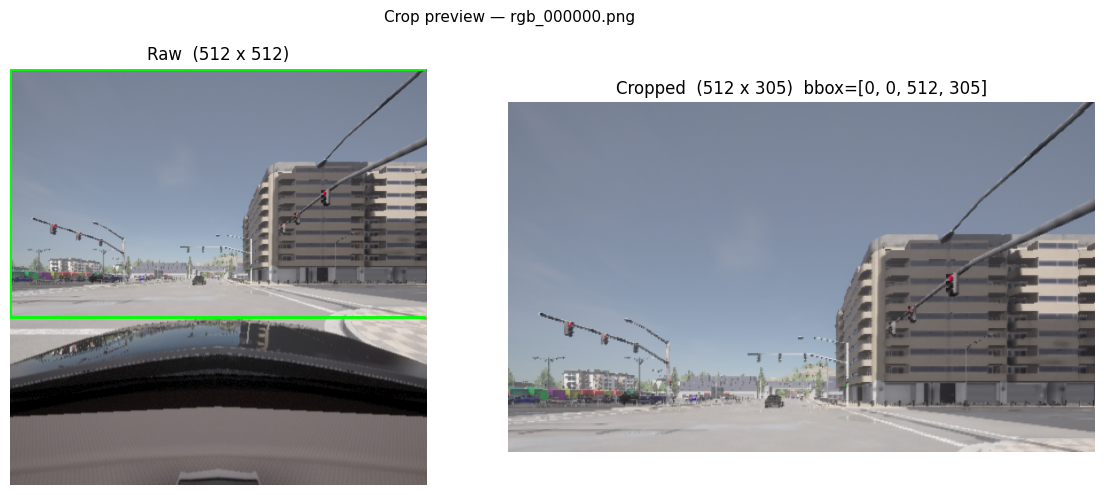

Preview frame: t:\TFG\MIREIA\trials\auto_17A_WetNoon_Town05_HighVol\runs\20260511_154256_base\images\rgb_000000.png


In [5]:
# Edit this bbox to match your dashcam framing, then re-run this cell to update
# the preview. Set to None to disable cropping (NOT recommended).
MANUAL_CROP_BBOX_XYXY: list[int] | None = [0, 0, 512, 305]

_preview_path = preview_manual_crop(MANUAL_CROP_BBOX_XYXY)
if _preview_path is not None:
    print(f"Preview frame: {_preview_path}")
else:
    print("No previously captured RGB frame available — run a base batch once "
          "and re-execute this cell to verify the crop.")

## 5 — Load Inference Models
`build_trial_predictors` constructs `QueuedE2ERiskInference` and `QueuedComposedBDUGRURiskInference` once with the same `manual_crop_bbox` defined above so streaming inference applies the same dashboard crop training did. Whichever predictor's checkpoint is missing is set to `None` and that model's run is skipped for every trial.

In [6]:
device_name = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device_name}")
print(f"manual_crop_bbox: {MANUAL_CROP_BBOX_XYXY}")

e2e_predictor, composed_predictor = build_trial_predictors(
    device=device_name,
    manual_crop_bbox=MANUAL_CROP_BBOX_XYXY,
)

print(f"E2E loaded:      {e2e_predictor is not None}")
print(f"Composed loaded: {composed_predictor is not None}")

if e2e_predictor is None and composed_predictor is None:
    raise RuntimeError("Both predictors are unavailable - cannot run.")

Device: cuda
manual_crop_bbox: [0, 0, 512, 305]
E2E loaded:      True
Composed loaded: True


### Per-Frame Predict Wrapper + Post-Run Cleanup
`make_predict_step_fn(predictor)` resets the queued predictor's temporal queue and returns a `Callable[[rgb_path], float | None]` suitable for `run_subtrial(predict_step_fn=...)`. The runner calls it every captured frame and stashes the result so the risk-aware speed modifier (which fires every tick) reads the most recent prediction.

`rename_predicted_risk(jsonl_path, new_field)` renames the JSONL's `predicted_risk` column to a model-specific name so the field is unambiguous downstream. Companion fields (`predicted_risk_window`, etc.) are dropped — only the scalar prediction survives the rename.

`cleanup_images(run_path)` deletes the run's `images/` directory; called when `SAVE_FRAMES=False`.

In [7]:
def make_predict_step_fn(queued_predictor) -> Callable[[str], float | None]:
    """Reset the predictor's queue and return a per-frame inference closure."""
    queued_predictor.reset_queue()

    def _predict(rgb_path: str) -> float | None:
        out = queued_predictor.add_image_path(rgb_path)
        if out.ready and out.latest_risk is not None:
            return float(out.latest_risk)
        return None

    return _predict


def rename_predicted_risk(jsonl_path: Path, new_field: str) -> int:
    """Rename `predicted_risk` -> `new_field` per record. Returns count of records renamed."""
    if not jsonl_path.is_file():
        return 0

    records = load_jsonl_records(str(jsonl_path))
    if not records:
        return 0

    drop_fields = (
        "predicted_risk_window",
        "predicted_risk_ready",
        "predicted_risk_buffer_size",
        "predicted_risk_error",
    )
    renamed = 0
    for rec in records:
        if "predicted_risk" in rec:
            rec[new_field] = rec.pop("predicted_risk")
            renamed += 1
        for k in drop_fields:
            rec.pop(k, None)

    with open(jsonl_path, "w", encoding="utf-8") as f:
        for rec in records:
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
    return renamed


def cleanup_images(run_path: Path) -> int:
    """Remove the run's images/ directory. Returns bytes freed (best-effort)."""
    images_dir = run_path / "images"
    if not images_dir.is_dir():
        return 0
    total = 0
    for p in images_dir.rglob("*"):
        if p.is_file():
            try:
                total += p.stat().st_size
            except OSError:
                pass
    shutil.rmtree(images_dir, ignore_errors=True)
    return total


@dataclass
class _ModelRun:
    name: str
    field: str                                        # JSONL field name after rename
    ego_cfg: EgoTrialConfig
    predictor: object | None
    speed_fn: Callable[[float, float | None], float]


print("Helpers ready: make_predict_step_fn(), rename_predicted_risk(), cleanup_images()")

Helpers ready: make_predict_step_fn(), rename_predicted_risk(), cleanup_images()


## 6 — Run Each Trial × Each Model
For every selected trial:
1. Build a fresh per-frame predict closure for the active model (resets the temporal queue per trial).
2. Run the subtrial with `predict_step_fn=...` and `risk_speed_fn=...` so the model's risk feeds the v' lambda live.
3. Rename `predicted_risk` → `predicted_risk_<model>` in the JSONL.
4. Optionally wipe the run's `images/` directory.

A predictor that didn't load is dropped from the schedule entirely. Per-(trial, model) failures are recorded and the batch keeps going.

In [8]:
all_summaries: list = []
inference_stats: dict[str, dict] = {}
failed: list[tuple[str, str, str]] = []

# Build the active model_runs from whichever predictors loaded.
model_runs: list[_ModelRun] = []
if e2e_predictor is not None:
    model_runs.append(_ModelRun(name="e2e", field="predicted_risk_e2e",
                                ego_cfg=e2e_ego_cfg, predictor=e2e_predictor,
                                speed_fn=e2e_speed_fn))
if composed_predictor is not None:
    model_runs.append(_ModelRun(name="composed", field="predicted_risk_composed",
                                ego_cfg=composed_ego_cfg, predictor=composed_predictor,
                                speed_fn=composed_speed_fn))

if not model_runs:
    raise RuntimeError("No predictors loaded - cannot run.")

# --- Run-time accounting -----------------------------------------------------
fixed_delta_s    = float(Config.SIM_FIXED_DELTA_SECONDS)
stride_ticks     = int(Config.RECORD_EVERY_N_TICKS)
sim_time_cap_s   = MAX_STEPS_PER_TRIAL * fixed_delta_s
max_jsonl_frames = MAX_STEPS_PER_TRIAL // stride_ticks
record_hz        = 1.0 / (fixed_delta_s * stride_ticks)
total_runs = len(selected_trial_names) * len(model_runs)

print("Run configuration:")
print(f"  fixed_delta:          {fixed_delta_s:.3f} s/tick  ({1/fixed_delta_s:.1f} Hz physics)")
print(f"  image_stride:         {stride_ticks} ticks/frame  ({record_hz:.2f} Hz JSONL records)")
print(f"  max_steps_per_trial:  {MAX_STEPS_PER_TRIAL}  (cap = {sim_time_cap_s:.1f} s sim, <= {max_jsonl_frames} JSONL frames)")
print(f"  models active:        {[m.name for m in model_runs]}")
print(f"  trials selected:      {len(selected_trial_names)}  ->  {total_runs} subtrial runs total")
print(f"  SAVE_FRAMES:          {SAVE_FRAMES}  ({'keep RGB+topdown' if SAVE_FRAMES else 'delete images/ after run'})")

_progress_state: dict = {"trial_started": 0.0}

def _format_secs(s: float) -> str:
    if s < 60:
        return f"{s:5.1f}s"
    m, sec = divmod(s, 60)
    return f"{int(m):02d}:{int(sec):02d}"

def _on_progress(step: int, max_steps: int) -> None:
    now = time.time()
    last = _progress_state.get("last_print", 0.0)
    if now - last < 0.2:
        return
    _progress_state["last_print"] = now
    elapsed = now - _progress_state["trial_started"]
    rate = step / elapsed if elapsed > 0 else 0.0
    pct = 100.0 * step / max_steps if max_steps else 0.0
    eta_to_cap = (max_steps - step) / rate if rate > 0 else float("inf")
    speedup = (step * fixed_delta_s) / elapsed if elapsed > 0 else 0.0
    sys.stdout.write(
        f"\r      step {step:5d}/{max_steps} ({pct:5.1f}% of cap)  "
        f"wall={_format_secs(elapsed)}  "
        f"rate={rate:5.1f} t/s  "
        f"speedup={speedup:4.2f}x  "
        f"eta_to_cap={_format_secs(eta_to_cap) if rate > 0 else '  inf'}    "
    )
    sys.stdout.flush()

batch_started = time.time()
run_idx = 0
for t_idx, trial_name in enumerate(selected_trial_names, start=1):
    print()
    print(f">>> [{t_idx}/{len(selected_trial_names)}] {trial_name}", flush=True)
    try:
        trial = TrialDefinition.load(trial_name)
    except Exception as e:
        for mr in model_runs:
            failed.append((trial_name, mr.name, f"load: {type(e).__name__}: {e}"))
        print(f"    [skip] failed to load trial: {type(e).__name__}: {e}")
        continue

    for mr in model_runs:
        run_idx += 1
        print(f"  -- model={mr.name}  ({run_idx}/{total_runs})", flush=True)
        _progress_state["trial_started"] = time.time()
        _progress_state["last_print"] = 0.0
        try:
            # Fresh per-trial predict closure (resets the temporal queue) so each
            # run starts from a clean burn-in instead of inheriting the previous trial.
            predict_fn = make_predict_step_fn(mr.predictor)

            summary = runner.run_subtrial(
                trial=trial,
                ego_cfg=mr.ego_cfg,
                max_steps=MAX_STEPS_PER_TRIAL,
                image_stride=Config.RECORD_EVERY_N_TICKS,
                store_rgb_images=True,                       # required by the streaming predictor
                store_topdown_images=SAVE_FRAMES,
                topdown_capture_delay_ticks=TOPDOWN_CAPTURE_DELAY,
                topdown_resolution=TOPDOWN_RESOLUTION,
                topdown_fov=TOPDOWN_FOV,
                topdown_align_risk_rotation=TOPDOWN_ALIGN_RISK,
                store_risk_frame_images=False,
                store_static_risk_map=False,
                draw_debug_every_tick=SAVE_FRAMES,           # only paint debug if frames are kept
                predict_step_fn=predict_fn,
                risk_speed_fn=mr.speed_fn,
                progress_callback=_on_progress,
                progress_every_n_steps=25,
            )
            elapsed = time.time() - _progress_state["trial_started"]
            sim_seconds = summary.num_frames * fixed_delta_s * stride_ticks
            speedup = sim_seconds / elapsed if elapsed > 0 else float("inf")
            sys.stdout.write("\r" + " " * 130 + "\r")
            sys.stdout.flush()

            jsonl_path = Path(summary.run_path) / "dataset.jsonl"
            renamed = rename_predicted_risk(jsonl_path, mr.field)
            inference_stats[f"{trial_name}|{mr.name}"] = {"frames": summary.num_frames, "predicted": renamed}

            print(
                f"      ok in {elapsed:6.1f}s wall  "
                f"frames={summary.num_frames:4d}  sim_t={sim_seconds:6.1f}s  "
                f"speedup={speedup:5.2f}x  dist={summary.traveled_m:7.1f}m  "
                f"{mr.field}={renamed}  finished={summary.finished}"
            )

            if not SAVE_FRAMES:
                freed = cleanup_images(Path(summary.run_path))
                print(f"      images/ wiped ({freed/1e6:.1f} MB freed)")

            all_summaries.append((trial_name, mr.name, summary))
        except Exception as e:
            elapsed = time.time() - _progress_state["trial_started"]
            sys.stdout.write("\r" + " " * 130 + "\r")
            sys.stdout.flush()
            print(f"      FAILED in {elapsed:.1f}s: {type(e).__name__}: {e}")
            failed.append((trial_name, mr.name, f"{type(e).__name__}: {e}"))

batch_elapsed = time.time() - batch_started
print()
print(f"Batch done in {batch_elapsed:.1f}s (ok={len(all_summaries)}, failed={len(failed)})")

Run configuration:
  fixed_delta:          0.050 s/tick  (20.0 Hz physics)
  image_stride:         5 ticks/frame  (4.00 Hz JSONL records)
  max_steps_per_trial:  6000  (cap = 300.0 s sim, <= 1200 JSONL frames)
  models active:        ['e2e', 'composed']
  trials selected:      20  ->  40 subtrial runs total
  SAVE_FRAMES:          False  (delete images/ after run)

>>> [1/20] auto_17A_WetNoon_Town05_HighVol
  -- model=e2e  (1/40)
Spawned ego vehicle 'vehicle.lincoln.mkz_2020' at index None (autopilot=False, tm_lights=False)
Spawned 80 / 80 requested vehicles.
ERROR: Spawn failed because of collision at spawn position
ERROR: Spawn failed because of collision at spawn position
ERROR: Spawn failed because of collision at spawn position
ERROR: Spawn failed because of collision at spawn position
ERROR: Spawn failed because of collision at spawn position
ERROR: Spawn failed because of collision at spawn position
ERROR: Spawn failed because of collision at spawn position
ERROR: Spawn failed b

## 7 — Summary

In [9]:
if not all_summaries and not failed:
    print("No trials were run.")
else:
    print(f"=== Successful runs ({len(all_summaries)}) ===")
    print(
        f"  {'trial_name':50s} {'model':>10s} {'frames':>6s} {'dist_m':>9s} "
        f"{'risk_auc':>9s} {'risk/m':>9s} {'preds':>6s}  finished  run_path"
    )
    for trial_name, model_name, s in all_summaries:
        stats = inference_stats.get(f"{trial_name}|{model_name}", {})
        preds = stats.get("predicted", 0)
        print(
            f"  {trial_name:50s} {model_name:>10s} {s.num_frames:6d} {s.traveled_m:9.1f} "
            f"{s.risk_auc:9.3f} {s.risk_per_meter:9.5f} {preds:6d}  "
            f"{str(s.finished):>8s}  {s.run_path}"
        )

    if failed:
        print()
        print(f"=== Failed runs ({len(failed)}) ===")
        for trial_name, model_name, err in failed:
            print(f"  {trial_name} / {model_name}: {err}")

=== Successful runs (39) ===
  trial_name                                              model frames    dist_m  risk_auc    risk/m  preds  finished  run_path
  auto_17A_WetNoon_Town05_HighVol                           e2e    396     544.5   238.993   2.59179    396      True  t:\TFG\MIREIA\trials\auto_17A_WetNoon_Town05_HighVol\runs\20260515_115553_e2e
  auto_17A_WetNoon_Town05_HighVol                      composed    394     549.5   237.058   2.65912    394      True  t:\TFG\MIREIA\trials\auto_17A_WetNoon_Town05_HighVol\runs\20260515_115941_composed
  auto_17B_WetNoon_Town05_LowVol                            e2e    145     560.1    67.084   2.04995    145      True  t:\TFG\MIREIA\trials\auto_17B_WetNoon_Town05_LowVol\runs\20260515_120509_e2e
  auto_17B_WetNoon_Town05_LowVol                       composed    141     557.9    63.310   1.97537    141      True  t:\TFG\MIREIA\trials\auto_17B_WetNoon_Town05_LowVol\runs\20260515_120629_composed
  auto_17C_WetNoon_Town10HD_HighVol            